# Smart Charging using Reinforcement Learning
Task description is summarized as follows:
- EV taxi is charged at home and an RL agent should manage the charging to complete the working day
- EV arrives at <b>2 p.m. at leaves at 4 p.m. each day</b>
- Adjustments to charging power can be made <b>every 15 minutes</b>
- Charging power is between 0 kW and 22 kW
- Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)
- Energy demand for after 4 pm is generated when leaving
- Running out of energy is the worst case -> high penalty
- Goal is to minimize recharging cost
- Vehicle's battery has a capacity that cannot be exceeded
- Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate 
- Create the environment (<b>simple discrete event simulation</b>) that returns agent's decisions and returns reward
- Define markov decision process, inclduing states, actions, and reward function
- Solve MDP using RL algorithm to find optimal charging policies
- Limited charging options such as zero, low, medium, high


Generally this tasks is splitted into three steps:
1. Simulation of the environment
2. Define Markov Decision Process
3. Let agents learn

As not all information are defined by the task, we work with assumptions.

> Assumption: We use a 60 kWh battery capacity which is in the middle of some german car manufacturer ([OPEL](https://www.opel.de/e-mobilitaet/elektro-modelle.html), [BMW](https://www.bmw.de/de/elektroauto.html#modelle))

> Assumption: There is no description about how much energy is left in the battery when the car arrives. Therefore we randomly select one based on the normal distribution, assuming that the taxi does a trip before 2 pm of the same scale.

> Assumption: The driver will not return with a completely empty battery, hence the minimum sampled will be 0.5 kWh.

> Assumption: As the vehicle is charged at home, we assume that the energy therefore alpha is set to 1

> Assumption: To avoid that the prices skyrock (e^22), we normalize it through the maximal power

> Assumption: Available battery capacity and charging speed decide about how much is actually charged. This estimated value is used for cost calculation.

In [1]:
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import simpy                                       
import gymnasium as gym                             
from gymnasium import spaces
from gymnasium.wrappers import TransformReward
import torch                                        
from stable_baselines3 import DQN                   
from stable_baselines3.common.monitor import Monitor
%matplotlib inline

import random
import math
from collections import deque
 
import numpy as np
import simpy
import torch
import torch.nn as nn
import torch.optim as optim
 
RANDOM_SEED = 42
BATTERY_CAPACITY = 60.0               # kWh - battery size

# 1. Simulation of the environment
Parameters and relevant design elements:
- Entity: Taxi with battery at the home charger
- Events:
    - Start event: Arrival at 2 pm
    - In-between events: Eight decision epochs - from start to end every 15min
    - End event:Departure at 4pm (stochastic demand is realised)
- Activity: Charging for 15 minute time slots at the given power
- Resource: Home charger and battery that cannot be exceeded


## 1.1 Stochastic distributions
### 1.1.1 Energy Demand
<i>"Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)"</i>

> Additional assumption was made that the driver will not return with a completely empty battery, hence the minimum sampled will be 0.5 kWh.

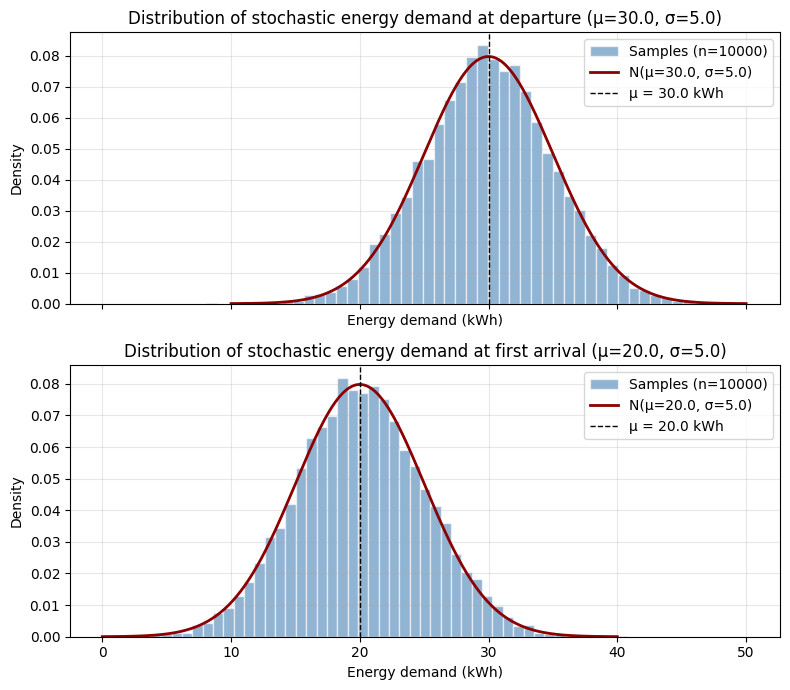

In [2]:
demand_rng = np.random.default_rng(RANDOM_SEED)

def sample_energy_demand(mu=30.0, sigma=5.0, generator=demand_rng, max_demand=BATTERY_CAPACITY):
    """
    Draw energy demand from a normal distribution, clipped to
    [0.5, max_demand] — can't be negative, and can't exceed
    the battery's maximum capacity (BATTERY_CAPACITY kWh).
    """
    demand = generator.normal(mu, sigma)
    return np.clip(demand, 0.5, max_demand)


# Plot departure
n_samples = 10000
mu = 30.0
sigma = 5.0
samples = np.array([sample_energy_demand(mu, sigma) for _ in range(n_samples)])

fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
ax[0].hist(samples, bins=50, density=True, alpha=0.6, color="steelblue", edgecolor="white", label=f"Samples (n={n_samples})")

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax[0].plot(x, pdf, color="darkred", lw=2, label=f"N(μ={mu}, σ={sigma})")

ax[0].axvline(mu, color="black", linestyle="--", lw=1, label=f"μ = {mu} kWh")
ax[0].set_xlabel("Energy demand (kWh)")
ax[0].set_ylabel("Density")
ax[0].set_title(f"Distribution of stochastic energy demand at departure (μ={mu}, σ={sigma})")
ax[0].legend()
ax[0].grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# Plot first arrival
n_samples = 10000
mu = 20.0
sigma = 5.0
samples = np.array([sample_energy_demand(mu, sigma) for _ in range(n_samples)])

ax[1].hist(samples, bins=50, density=True, alpha=0.6, color="steelblue", edgecolor="white", label=f"Samples (n={n_samples})")

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax[1].plot(x, pdf, color="darkred", lw=2, label=f"N(μ={mu}, σ={sigma})")

ax[1].axvline(mu, color="black", linestyle="--", lw=1, label=f"μ = {mu} kWh")
ax[1].set_xlabel("Energy demand (kWh)")
ax[1].set_ylabel("Density")
ax[1].set_title(f"Distribution of stochastic energy demand at first arrival (μ={mu}, σ={sigma})")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.1.2 Recharging costs
"Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate"

> Assumption: As the vehicle is charged at home, we assume that the energy therefore alpha is set to 1

> Assumption: To avoid that the prices skyrock (e^22), we normalize it through the maximal power

> Assumption: Available battery capacity and charging speed decide about how much is actually charged. This estimated value is used for cost calculation.

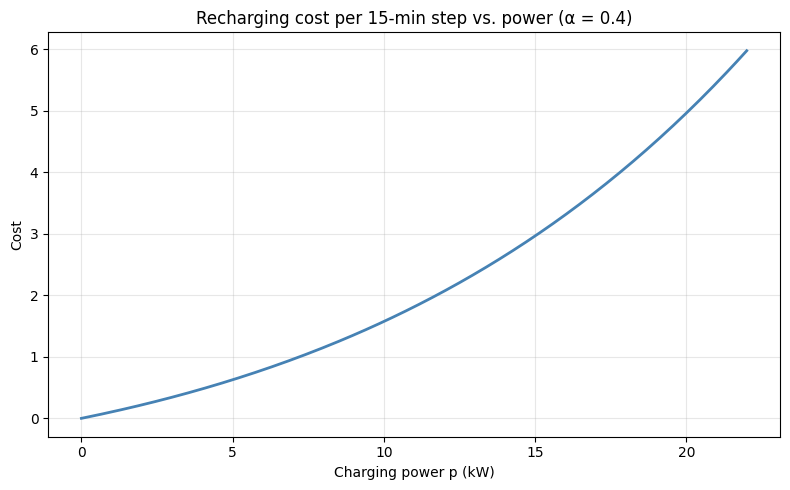

In [3]:
ALPHA = 0.4    # time coefficient alpha_t, constant over time
P_MAX = 22.0   # kW, highest charging rate
DT = 0.25      # hours per 15-min decision step


def charged_energy(power, soc, capacity=BATTERY_CAPACITY, dt=DT):
    """
    Calculates the energy that can be charged in a single step,
    given the charging power and the available space in the battery (capacity - soc). 
    """
    space = np.maximum(0.0, capacity - soc)
    return np.minimum(power * dt, space)


def charging_cost(power, energy, alpha=ALPHA, p_max=P_MAX):
    """
    Calculates the cost of charging a given amount of energy at a given power level,
    using a cost function that increases exponentially with power.
    """
    return alpha * energy * np.exp(power / p_max)



powers = np.linspace(0, P_MAX, 200)
costs = charging_cost(powers, charged_energy(powers, soc=0.0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(powers, costs, color="steelblue", lw=2)
ax.set_xlabel("Charging power p (kW)")
ax.set_ylabel("Cost")
ax.set_title(f"Recharging cost per 15-min step vs. power (α = {ALPHA})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
STEP_MINUTES = 15                     # agent re-decides charging power every 15 min
SESSION_MINUTES = 120                 # car is home from 2:00pm to 4:00pm
N_STEPS = SESSION_MINUTES // STEP_MINUTES     # 8 decision points per day

ACTION_POWERS = [0.0, 4.4, 8.8, 13.2, 17.6, 22.0]
ACTION_LABELS = ["zero", "very low", "low", "medium", "high", "very high"]

N_ACTIONS = len(ACTION_POWERS)

PENALTY_PER_KWH = 700.0               # penalty for every KWh of unmet demand

As some information are not explicitly given by the task description we work with additional assumptions.
> Assumption: There is no description about how much energy is left in the battery when the car arrives. Therefore we randomly select one based on the normal distribution, assuming that the taxi does a trip before 2 pm of the same scale.

# 2. Markov Decision Process

The environment is implemented as a `gymnasium.Env` so that it can be handed directly to a Stable-Baselines3 agent.

**State** $s_t = (t,\ soc_t)$, normalised to $[0,1]$ as $(t/8,\ soc/60)$.

The realised demand is *not* part of the state but is calculated at departure. So the agent is limited to knowing that the time step and the demand.

**Action** $a_t \in \{0,\dots,5\}$. The agent has the possible actions of charging at different speeds: 0 / 4.4 / 8.8 / 13.2 / 17.6 / 22.0 kW 

**Transition** $soc_{t+1} = soc_t + \min(p_{a}\cdot \Delta t,\ 60 - soc_t)$, with $\Delta t = 0.25$ h. Battery capacity is enforced inside `charged_energy()`, so the state can not be overcharged.

**Reward**
Reward consists of negative costs and the penalty which is set for `700 * kWh_missed`

$$r_t = -\alpha \cdot e_t \cdot e^{p_t/p_{max}} \qquad\text{for } t < 8$$

$$r_8 = -\alpha \cdot e_8 \cdot e^{p_8/p_{max}} - 700 \cdot \max(0,\ D - soc_8), \qquad D \sim \mathcal{N}(30, 5)$$

**Horizon** 8 steps, finite and fixed, so every episode terminates at 4 pm (`terminated=True`); `truncated` is always `False` since there is no external time limit.

In [5]:
class ChargingEnv(gym.Env):
    """
    Gymnasium environment for the smart-charging MDP.

    The agent picks a charging power every 15 minutes; the environment returns
    the resulting state, reward and termination flag.

    Each step follows three stages:
      1. the agent selects a charging power,
      2. `charged_energy()` estimates how much the battery absorbs in the
         coming 15 minutes (this is where the step length dt enters),
      3. `charging_cost()` prices that energy at the flat tariff ALPHA.

    At departure (t = N_STEPS) the stochastic demand is realised and any
    unmet energy is penalised at PENALTY_PER_KWH.
    """

    metadata = {"render_modes": []}

    def __init__(self, verbose=False):
        super().__init__()
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(2,), dtype=np.float32)
        self.verbose = verbose
        self.rng = np.random.default_rng(RANDOM_SEED)   # must be set once to ensure proper reproducibility
        self.time = 0
        self.state_of_charge = sample_energy_demand(mu=20, sigma=5, generator=self.rng)

    def _obs(self):
        """Scale (t, soc) to [0, 1] for the neural network."""
        return np.array(
            [self.time / N_STEPS, self.state_of_charge / BATTERY_CAPACITY],
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.time = 0

        self.state_of_charge = float(sample_energy_demand(mu=20, sigma=5, generator=self.rng)) # Select base energy from normal distribution
        return self._obs(), {}

    def step(self, action):
        # Select charging power
        power = ACTION_POWERS[int(action)]

        # Calculate possible energy charged in this step and price
        energy = float(charged_energy(power, self.state_of_charge))
        cost = float(charging_cost(power, energy))

        self.state_of_charge += energy  # no battery overflow, see charged_energy()
        self.time += 1

        reward = -cost
        terminated = self.time >= N_STEPS   # episode ends at departure (4 pm)
        truncated = False                   # no external time limit
        info = {
            "power": power,
            "energy": energy,
            "cost": cost,
            "battery_full": self.state_of_charge >= BATTERY_CAPACITY,
            "demand": None,
            "shortfall": None,
            "penalty": 0.0,
        }

        # Terminate = departure: realise stochastic demand and penalise unmet energy
        if terminated:
            demand = float(sample_energy_demand(mu=30, sigma=5, generator=self.rng))
            shortfall = max(0.0, demand - self.state_of_charge)
            penalty = PENALTY_PER_KWH * shortfall
            reward -= penalty
            info.update(demand=demand, shortfall=shortfall, penalty=penalty)

        if self.verbose:
            print(f"Step {self.time}: Action={ACTION_LABELS[int(action)]}, "
                  f"Power={power:.1f} kW, Energy={energy:.2f} kWh, Cost={cost:.2f}")

        return self._obs(), reward, terminated, truncated, info

# 3. Baseline: evenly distributed charging

To have a baseline, we set the simple rule to charge as much as possible evenly distributed over the 8 time slots.
So on arrival we calculate the energy missing to a full battery and divide it by 8. That gives the kWh per slot; dividing by the slot length $\Delta t = 0.25$ h turns it into the charging power the rule holds for the whole session:

$$p = \frac{60 - soc_0}{8 \cdot \Delta t}$$

If that value is above 22 kW, the rule simply charges as much as possible.

Since the available powers are discrete, the required power is rounded up to the next level, so the baseline slightly overshoots the target rather than undershooting it.

The rule uses only the arrival SoC and never re-plans. It should almost never run out of energy, but it pays for a full battery every day.

In [6]:
def even_spread_action(soc_arrival, capacity=BATTERY_CAPACITY):
    """
    Baseline rule, decided once on arrival at 2 pm.

    The energy missing to a full battery is spread evenly over the 8 slots.
    Dividing by N_STEPS gives the kWh per slot, dividing by DT turns that into
    the kW the charger has to hold. If more than the strongest level would be
    needed, charge as much as possible instead.
    """
    missing_energy = max(0.0, capacity - soc_arrival)   # kWh
    energy_per_step = missing_energy / N_STEPS          # kWh per 15-min slot
    required_power = energy_per_step / DT               # kW held constant for 2 h

    for idx, power in enumerate(ACTION_POWERS):
        if power >= required_power - 1e-9:
            return idx
    return N_ACTIONS - 1                                # > 22 kW needed -> charge flat out


def run_baseline(n_episodes=5000, seed=RANDOM_SEED):
    """Roll out the baseline policy on ChargingEnv and collect per-episode results."""
    env = ChargingEnv()
    records = []

    for episode in range(n_episodes):
        env.reset(seed=seed + episode)
        soc_arrival = env.state_of_charge

        action = even_spread_action(soc_arrival)   # decided once at 2 pm, then held
        cost = 0.0
        while True:
            _, _, terminated, _, info = env.step(action)
            cost += info["cost"]
            if terminated:
                break

        records.append({
            "arrival_soc": soc_arrival,
            "power": ACTION_POWERS[action],
            "final_soc": env.state_of_charge,
            "demand": info["demand"],
            "cost": cost,
            "shortfall": info["shortfall"],
            "penalty": info["penalty"],
            "reward": -(cost + info["penalty"]),
        })

    return pd.DataFrame(records)


def _dist_row(name, series, unit=""):
    """Format one distribution row (mean + p5/p50/p95 + max) for a per-episode Series."""
    q = series.quantile([0.05, 0.5, 0.95])
    return (f"  {name:<16} mean {series.mean():8.2f} | "
            f"p5 {q.loc[0.05]:8.2f} | p50 {q.loc[0.50]:8.2f} | "
            f"p95 {q.loc[0.95]:8.2f} | max {series.max():8.2f} {unit}")


baseline = run_baseline()

print(f"Baseline: evenly spread charging to a full battery, {len(baseline)} episodes\n")
print(f"mean charging cost   {baseline['cost'].mean():8.2f}")
print(f"mean penalty         {baseline['penalty'].mean():8.2f}")
print(f"mean total reward    {baseline['reward'].mean():8.2f}")
print(f"episodes w/ shortfall{baseline['shortfall'].gt(0).mean():8.2%}")
print(f"mean shortfall       {baseline['shortfall'].mean():8.3f} kWh")
print(f"mean arrival SoC     {baseline['arrival_soc'].mean():8.2f} kWh")
print(f"mean final SoC       {baseline['final_soc'].mean():8.2f} kWh")

Baseline: evenly spread charging to a full battery, 5000 episodes

mean charging cost      41.77
mean penalty             0.00
mean total reward      -41.77
episodes w/ shortfall   0.00%
mean shortfall          0.000 kWh
mean arrival SoC        20.01 kWh
mean final SoC          59.42 kWh


In [7]:
baseline.describe()

,arrival_soc,power,final_soc,demand,cost,shortfall,penalty,reward
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000
mean,20.013908,21.254640,59.418912,29.897190,41.773324,0.0,0.0,-41.773324
std,4.966927,1.712804,1.547606,5.036867,6.477373,0.0,0.0,6.477373
min,0.500000,8.800000,44.500000,11.844948,10.279489,0.0,0.0,-47.841760
25%,16.655863,22.000000,60.000000,26.453304,39.866640,0.0,0.0,-47.128631
50%,19.984372,22.000000,60.000000,29.866849,43.509502,0.0,0.0,-43.509502
75%,23.334707,22.000000,60.000000,33.239110,47.128631,0.0,0.0,-39.866640
max,42.773631,22.000000,60.000000,47.624110,47.841760,0.0,0.0,-10.279489


# 4. Monte Carlo
Reasons why Monte Carlo is applicable:
- Complete eposiodes from arrival to leaving, 8 time-steps
- Return of an episode is the sum of all reparts (charging costs + penalty) which is propagated back to earlier decisions through the mean calculation at every state
- State consists of t and SoC is discrete: 
    - SoC bin size is derived from the action grid as the weakest non-zero charging level $(DT*p=kWh)$
    - Time bins are the 8 time-steps
- Actions are choosen epsilon-greedy during training
 

In [8]:
SMALLEST_POWER = min(p for p in ACTION_POWERS if p > 0)   # 4.4 kW, weakest non-zero charging level
SOC_BIN_SIZE = SMALLEST_POWER * DT                        # 1.1 kWh added by that level in one 15-min step
N_SOC_BINS = int(BATTERY_CAPACITY / SOC_BIN_SIZE) + 1     # 55 bins covering 0..60 kWh

EPSILON = 0.1              # default exploration rate, replaced by the grid search below
DISCOUNT_FACTOR = 0.9      # default discount factor, replaced by the grid search below


def discretize(time, soc):
    """Map the continuous state (t, soc) onto the tabular state (t, soc_bin).""" 
    return time, min(int(soc / SOC_BIN_SIZE), N_SOC_BINS - 1)


def train_monte_carlo(n_episodes=300_000, epsilon=EPSILON, discount_factor=DISCOUNT_FACTOR,
                      seed=RANDOM_SEED):
    """
    On-policy Monte Carlo control with an epsilon-greedy policy and discount factor.
    """
    # Environment
    env = ChargingEnv()
    env.reset(seed=seed)
    random_generator = np.random.default_rng(seed)

    action_values = np.zeros((N_STEPS, N_SOC_BINS, N_ACTIONS))   # expected return per state-action pair
    visit_counts = np.zeros((N_STEPS, N_SOC_BINS, N_ACTIONS))                # how often each pair was seen

    # Run episodes
    for episode_index in range(n_episodes):
        env.reset()
        episode_trajectory = []
        terminated = False
        while not terminated:
            state = discretize(env.time, env.state_of_charge)
            if random_generator.random() < epsilon:
                action = int(random_generator.integers(N_ACTIONS))   # explore
            else:
                action = int(np.argmax(action_values[state]))        # exploit
            _, reward, terminated, _, _ = env.step(action)
            episode_trajectory.append((state, action, reward))

        # walk backwards through the episode and update with the realised return
        episode_return = 0.0
        for state, action, reward in reversed(episode_trajectory):
            episode_return = reward + discount_factor * episode_return
            visit_counts[state][action] += 1
            action_values[state][action] += (
                (episode_return - action_values[state][action]) / visit_counts[state][action]
            )

    return action_values


def run_monte_carlo(action_values, n_episodes=5000, seed=RANDOM_SEED):
    """Roll out the greedy policy learned by Monte Carlo control and collect per-episode results."""
    env = ChargingEnv()
    records = []

    for episode in range(n_episodes):
        env.reset(seed=seed + episode)
        soc_arrival = env.state_of_charge

        total_cost = 0.0
        step_powers = []
        while True:
            state = discretize(env.time, env.state_of_charge)
            action = int(np.argmax(action_values[state]))   # greedy, re-decided every 15 min
            _, _, terminated, _, info = env.step(action)
            total_cost += info["cost"]
            step_powers.append(info["power"])
            if terminated:
                break

        records.append({
            "arrival_soc": soc_arrival,
            "power": float(np.mean(step_powers)),
            "final_soc": env.state_of_charge,
            "demand": info["demand"],
            "cost": total_cost,
            "shortfall": info["shortfall"],
            "penalty": info["penalty"],
            "reward": -(total_cost + info["penalty"]),
        })

    return pd.DataFrame(records)


print(f"SoC bin size: {SOC_BIN_SIZE:.2f} kWh -> {N_SOC_BINS} bins")

SoC bin size: 1.10 kWh -> 55 bins


## 4.1 Hyperparameter optimization

Grid search over the exploration rate and the discount factor:
- Epsilon: 0.0, 0.05, 0.1, 0.2, 0.3
- Gamma: 1.0, 0.95, 0.9, 0.8, 0.7
- Every combination is trained from scratch and its greedy policy is evaluated on the same episodes
- Training uses fewer episodes than the final run to keep the 25 combinations tractable
- The best combination is used for the final training in 4.2

In [9]:
EPSILON_GRID = [0.0, 0.05, 0.1, 0.2, 0.3]
GAMMA_GRID = [1.0, 0.95, 0.9, 0.8, 0.7]

SEARCH_TRAIN_EPISODES = 100_000   # per combination, lower than the final run
SEARCH_EVAL_EPISODES = 5000       # evaluation episodes per combination

search_records = []

for epsilon in EPSILON_GRID:
    for gamma in GAMMA_GRID:
        candidate_values = train_monte_carlo(
            n_episodes=SEARCH_TRAIN_EPISODES,
            epsilon=epsilon,
            discount_factor=gamma,
        )
        results = run_monte_carlo(candidate_values, n_episodes=SEARCH_EVAL_EPISODES)

        search_records.append({
            "epsilon": epsilon,
            "gamma": gamma,
            "cost": results["cost"].mean(),
            "penalty": results["penalty"].mean(),
            "reward": results["reward"].mean(),
            "shortfall_share": results["shortfall"].gt(0).mean(),
            "final_soc": results["final_soc"].mean(),
        })
        print(f"epsilon {epsilon:.2f} | gamma {gamma:.2f} -> reward {search_records[-1]['reward']:8.2f}")

hyperparameter_search = pd.DataFrame(search_records).sort_values("reward", ascending=False)

best_epsilon = float(hyperparameter_search.iloc[0]["epsilon"])
best_gamma = float(hyperparameter_search.iloc[0]["gamma"])
best_reward = float(hyperparameter_search.iloc[0]["reward"])

print(f"\nBest combination: epsilon {best_epsilon:.2f}, gamma {best_gamma:.2f} "
      f"with mean reward {best_reward:.2f}")
print(f"Spread over all {len(hyperparameter_search)} combinations: "
      f"{hyperparameter_search['reward'].min():.2f} to {hyperparameter_search['reward'].max():.2f}")

epsilon 0.00 | gamma 1.00 -> reward   -21.56
epsilon 0.00 | gamma 0.95 -> reward   -21.27
epsilon 0.00 | gamma 0.90 -> reward   -21.97
epsilon 0.00 | gamma 0.80 -> reward   -20.70
epsilon 0.00 | gamma 0.70 -> reward   -21.27
epsilon 0.05 | gamma 1.00 -> reward   -21.88
epsilon 0.05 | gamma 0.95 -> reward   -21.73
epsilon 0.05 | gamma 0.90 -> reward   -21.57
epsilon 0.05 | gamma 0.80 -> reward   -22.59
epsilon 0.05 | gamma 0.70 -> reward   -21.62
epsilon 0.10 | gamma 1.00 -> reward   -21.99
epsilon 0.10 | gamma 0.95 -> reward   -21.33
epsilon 0.10 | gamma 0.90 -> reward   -22.18
epsilon 0.10 | gamma 0.80 -> reward   -21.59
epsilon 0.10 | gamma 0.70 -> reward   -22.12
epsilon 0.20 | gamma 1.00 -> reward   -22.08
epsilon 0.20 | gamma 0.95 -> reward   -21.58
epsilon 0.20 | gamma 0.90 -> reward   -22.78
epsilon 0.20 | gamma 0.80 -> reward   -20.78
epsilon 0.20 | gamma 0.70 -> reward   -21.54
epsilon 0.30 | gamma 1.00 -> reward   -22.19
epsilon 0.30 | gamma 0.95 -> reward   -21.49
epsilon 0.

In [10]:
hyperparameter_search.pivot(index="epsilon", columns="gamma", values="reward").round(2)

gamma,0.70,0.80,0.90,0.95,1.00
epsilon,,,,,
0.00,-21.27,-20.70,-21.97,-21.27,-21.56
0.05,-21.62,-22.59,-21.57,-21.73,-21.88
0.10,-22.12,-21.59,-22.18,-21.33,-21.99
0.20,-21.54,-20.78,-22.78,-21.58,-22.08
0.30,-21.34,-20.99,-21.05,-21.49,-22.19


## 4.2 Final training and evaluation

- The agent is trained one last time with the best combination from the grid search, using the full number of episodes
- The resulting greedy policy is evaluated on the same episodes as the baseline

In [11]:
mc_action_values = train_monte_carlo(
    n_episodes=300_000,
    epsilon=best_epsilon,
    discount_factor=best_gamma,
)

print(f"Final training with epsilon {best_epsilon:.2f} and gamma {best_gamma:.2f}")
print(f"Trained action-value table: {mc_action_values.shape} (time steps x SoC bins x actions)\n")

monte_carlo = run_monte_carlo(mc_action_values)

print(f"Monte Carlo: greedy policy from tabular MC control, {len(monte_carlo)} episodes\n")
print(f"mean charging cost   {monte_carlo['cost'].mean():8.2f}")
print(f"mean penalty         {monte_carlo['penalty'].mean():8.2f}")
print(f"mean total reward    {monte_carlo['reward'].mean():8.2f}")
print(f"episodes w/ shortfall{monte_carlo['shortfall'].gt(0).mean():8.2%}")
print(f"mean shortfall       {monte_carlo['shortfall'].mean():8.3f} kWh")
print(f"mean arrival SoC     {monte_carlo['arrival_soc'].mean():8.2f} kWh")
print(f"mean final SoC       {monte_carlo['final_soc'].mean():8.2f} kWh")

Final training with epsilon 0.00 and gamma 0.80
Trained action-value table: (8, 55, 6) (time steps x SoC bins x actions)

Monte Carlo: greedy policy from tabular MC control, 5000 episodes

mean charging cost      19.48
mean penalty             1.22
mean total reward      -20.70
episodes w/ shortfall   0.16%
mean shortfall          0.002 kWh
mean arrival SoC        20.01 kWh
mean final SoC          44.96 kWh


In [12]:
monte_carlo.describe()

,arrival_soc,power,final_soc,demand,cost,shortfall,penalty,reward
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.013908,12.471250,44.956408,29.897190,19.482407,0.001737,1.215740,-20.698146
std,4.966927,2.316233,0.616959,5.036867,5.230425,0.050012,35.008713,35.360505
min,0.500000,3.300000,43.400000,11.844948,5.229758,0.000000,0.000000,-1436.010968
25%,16.655863,11.000000,44.452516,26.453304,15.964401,0.000000,0.000000,-22.879937
50%,19.984372,12.100000,44.875514,29.866849,18.212523,0.000000,0.000000,-18.212523
75%,23.334707,13.750000,45.436657,33.239110,22.879937,0.000000,0.000000,-15.964401
max,42.773631,21.450000,49.373631,47.624110,45.778492,2.025426,1417.798445,-5.229758


# 5. DQN

Reasons why a DQN is applicable:
- The SoC is continuous, the network takes the normalised state directly and does not need the binning the tabular agent depends on
- The network generalises between similar states, so experience made at one SoC also improves neighbouring states instead of only filling one table cell
- Learning happens from single transitions stored in a replay buffer, so the agent already updates during the day instead of only after departure
- The task description explicitly suggests a deep Q-network as the solver

Reasons for the chosen setup:
- `MlpPolicy` with two hidden layers of 64 units, small but more than enough for a two-dimensional state and six actions
- `exploration_fraction` of 0.3 lets epsilon decay over the first third of the training and stay constant afterwards
- `target_update_interval` of 500 keeps the bootstrap target stable relative to the short 8-step episodes
- `buffer_size` of 50000 holds roughly 6000 complete days, so the replay buffer covers many different arrival states
- Learning rate, final exploration rate, gamma and reward scale are not fixed here but decided by the grid search in 5.1

> Assumption: The rewards span three orders of magnitude, from about 2 for a cheap charging step up to over 1000 for a shortfall. The default Huber loss treats all large errors alike, so the rare but decisive penalty is learned too weakly and the agent systematically undercharges. Multiplying all rewards by a constant reward scale brings them into a range where the loss stays sensitive to the penalty. The scaling is applied during training only, all reported statistics use the unscaled values.

In [13]:
REWARD_SCALE = 0.002        # shrinks the reward range so the loss stays sensitive to the penalty
DQN_DISCOUNT_FACTOR = 1.0   # undiscounted, the departure penalty counts in full


def train_dqn(total_timesteps, learning_rate, exploration_final_eps,
              discount_factor=DQN_DISCOUNT_FACTOR, reward_scale=REWARD_SCALE, seed=RANDOM_SEED):
    """
    Train a DQN on the charging environment.

    The environment is wrapped in TransformReward so the network sees scaled
    rewards during training, while the evaluation later uses the raw values.
    """
    training_env = TransformReward(ChargingEnv(), lambda reward: reward * reward_scale)

    model = DQN(
        "MlpPolicy",
        training_env,
        learning_rate=learning_rate,
        gamma=discount_factor,
        buffer_size=50_000,
        learning_starts=1_000,
        batch_size=64,
        train_freq=4,
        target_update_interval=500,
        exploration_fraction=0.3,
        exploration_final_eps=exploration_final_eps,
        policy_kwargs=dict(net_arch=[64, 64]),
        seed=seed,
        verbose=0,
    )
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    return model


def run_dqn(model, n_episodes=5000, seed=RANDOM_SEED):
    """Roll out the trained DQN greedily and collect per-episode results, same format as the baseline."""
    env = ChargingEnv()
    records = []

    for episode in range(n_episodes):
        observation, _ = env.reset(seed=seed + episode)
        soc_arrival = env.state_of_charge

        total_cost = 0.0
        step_powers = []
        while True:
            action, _ = model.predict(observation, deterministic=True)   # greedy, no exploration
            observation, _, terminated, _, info = env.step(int(action))
            total_cost += info["cost"]
            step_powers.append(info["power"])
            if terminated:
                break

        records.append({
            "arrival_soc": soc_arrival,
            "power": float(np.mean(step_powers)),
            "final_soc": env.state_of_charge,
            "demand": info["demand"],
            "cost": total_cost,
            "shortfall": info["shortfall"],
            "penalty": info["penalty"],
            "reward": -(total_cost + info["penalty"]),
        })

    return pd.DataFrame(records)


print(f"Reward scale: {REWARD_SCALE} | discount factor: {DQN_DISCOUNT_FACTOR}")

Reward scale: 0.002 | discount factor: 1.0


## 5.1 Hyperparameter optimization

Grid search over the four parameters that decide how well the penalty is learned:
- Learning rate: 0.001, 0.0005
- Final exploration rate: 0.05, 0.15
- Gamma: 1.0, 0.9
- Reward scale: 0.01, 0.002

Reasons for searching exactly these:
- Learning rate and final exploration rate control how fast and how broadly the network keeps sampling shortfall situations
- Gamma decides how strongly the departure penalty still counts at the early decision steps
- Reward scale decides whether the Huber loss stays sensitive to the rare penalty at all, which turned out to be the difference between a working and a permanently undercharging agent
- The remaining settings (network size, buffer size, target update interval, exploration fraction) are kept fixed, they showed no comparable effect and every extra dimension doubles the runtime

All 16 combinations are trained from scratch and evaluated greedily on the same episodes.

In [ ]:
from itertools import product

DQN_LEARNING_RATE_GRID = [1e-3, 5e-4]
DQN_EXPLORATION_FINAL_EPS_GRID = [0.05, 0.15]
DQN_GAMMA_GRID = [1.0, 0.9]
DQN_REWARD_SCALE_GRID = [0.01, 0.002]

DQN_SEARCH_TIMESTEPS = 100_000    # per combination, lower than the final run
DQN_SEARCH_EVAL_EPISODES = 2000   # evaluation episodes per combination

dqn_search_grid = list(product(
    DQN_LEARNING_RATE_GRID,
    DQN_EXPLORATION_FINAL_EPS_GRID,
    DQN_GAMMA_GRID,
    DQN_REWARD_SCALE_GRID,
))
print(f"Searching {len(dqn_search_grid)} combinations\n")

dqn_search_records = []

for learning_rate, exploration_final_eps, gamma, reward_scale in dqn_search_grid:
    candidate_model = train_dqn(
        total_timesteps=DQN_SEARCH_TIMESTEPS,
        learning_rate=learning_rate,
        exploration_final_eps=exploration_final_eps,
        discount_factor=gamma,
        reward_scale=reward_scale,
    )
    results = run_dqn(candidate_model, n_episodes=DQN_SEARCH_EVAL_EPISODES)

    dqn_search_records.append({
        "learning_rate": learning_rate,
        "final_eps": exploration_final_eps,
        "gamma": gamma,
        "reward_scale": reward_scale,
        "cost": results["cost"].mean(),
        "penalty": results["penalty"].mean(),
        "reward": results["reward"].mean(),
        "shortfall_share": results["shortfall"].gt(0).mean(),
        "final_soc": results["final_soc"].mean(),
    })
    print(f"lr {learning_rate:.4f} | final eps {exploration_final_eps:.2f} | "
          f"gamma {gamma:.2f} | scale {reward_scale:.3f} "
          f"-> reward {dqn_search_records[-1]['reward']:9.2f} "
          f"| shortfall {dqn_search_records[-1]['shortfall_share']:.2%}")

dqn_hyperparameter_search = pd.DataFrame(dqn_search_records).sort_values("reward", ascending=False)

best_dqn_learning_rate = float(dqn_hyperparameter_search.iloc[0]["learning_rate"])
best_dqn_final_eps = float(dqn_hyperparameter_search.iloc[0]["final_eps"])
best_dqn_gamma = float(dqn_hyperparameter_search.iloc[0]["gamma"])
best_dqn_reward_scale = float(dqn_hyperparameter_search.iloc[0]["reward_scale"])
best_dqn_reward = float(dqn_hyperparameter_search.iloc[0]["reward"])

print(f"\nBest combination: learning rate {best_dqn_learning_rate:.4f}, "
      f"final eps {best_dqn_final_eps:.2f}, gamma {best_dqn_gamma:.2f}, "
      f"reward scale {best_dqn_reward_scale:.3f} with mean reward {best_dqn_reward:.2f}")
print(f"Spread over all {len(dqn_hyperparameter_search)} combinations: "
      f"{dqn_hyperparameter_search['reward'].min():.2f} to "
      f"{dqn_hyperparameter_search['reward'].max():.2f}")

Searching 16 combinations

lr 0.0010 | final eps 0.05 | gamma 1.00 | scale 0.010 -> reward    -54.36 | shortfall 2.60%
lr 0.0010 | final eps 0.05 | gamma 1.00 | scale 0.002 -> reward    -26.80 | shortfall 0.95%
lr 0.0010 | final eps 0.05 | gamma 0.90 | scale 0.010 -> reward    -37.94 | shortfall 1.30%


In [ ]:
dqn_hyperparameter_search.pivot_table(
    index=["learning_rate", "final_eps"],
    columns=["gamma", "reward_scale"],
    values="reward",
).round(2)

## 5.2 Final training and evaluation

- The DQN is trained one last time with the best combination from the grid search, using twice the training steps
- The resulting greedy policy is evaluated on the same episodes as the baseline and the Monte Carlo agent

In [ ]:
DQN_FINAL_TIMESTEPS = 200_000

dqn_model = train_dqn(
    total_timesteps=DQN_FINAL_TIMESTEPS,
    learning_rate=best_dqn_learning_rate,
    exploration_final_eps=best_dqn_final_eps,
    discount_factor=best_dqn_gamma,
    reward_scale=best_dqn_reward_scale,
)

print(f"Final training with learning rate {best_dqn_learning_rate:.4f}, "
      f"final eps {best_dqn_final_eps:.2f}, gamma {best_dqn_gamma:.2f}, "
      f"reward scale {best_dqn_reward_scale:.3f} over {DQN_FINAL_TIMESTEPS} steps\n")

dqn = run_dqn(dqn_model)

print(f"DQN: greedy policy from the trained network, {len(dqn)} episodes\n")
print(f"mean charging cost   {dqn['cost'].mean():8.2f}")
print(f"mean penalty         {dqn['penalty'].mean():8.2f}")
print(f"mean total reward    {dqn['reward'].mean():8.2f}")
print(f"episodes w/ shortfall{dqn['shortfall'].gt(0).mean():8.2%}")
print(f"mean shortfall       {dqn['shortfall'].mean():8.3f} kWh")
print(f"mean arrival SoC     {dqn['arrival_soc'].mean():8.2f} kWh")
print(f"mean final SoC       {dqn['final_soc'].mean():8.2f} kWh")

In [ ]:
dqn.describe()